In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

### Task 2

In [3]:
data = {
    "month": [
        "2023-01", "2023-02", "2023-03", "2023-04",
        "2023-05", "2023-06", "2023-07", "2023-08",
        "2023-09", "2023-10", "2023-11", "2023-12"
    ],
    "visits": [
        1200, 1350, 1100, 980,
        870, 760, 800, 950,
        1050, 1300, 1600, 1750
    ]
}

df_visits = pd.DataFrame(data)
df_visits["month"] = pd.to_datetime(df_visits["month"])

print(df_visits.dtypes)
print(df_visits.head())

month     datetime64[ns]
visits             int64
dtype: object
       month  visits
0 2023-01-01    1200
1 2023-02-01    1350
2 2023-03-01    1100
3 2023-04-01     980
4 2023-05-01     870


1. month shows datetime64
2. Datetime being a month is used for time series

### Task 3

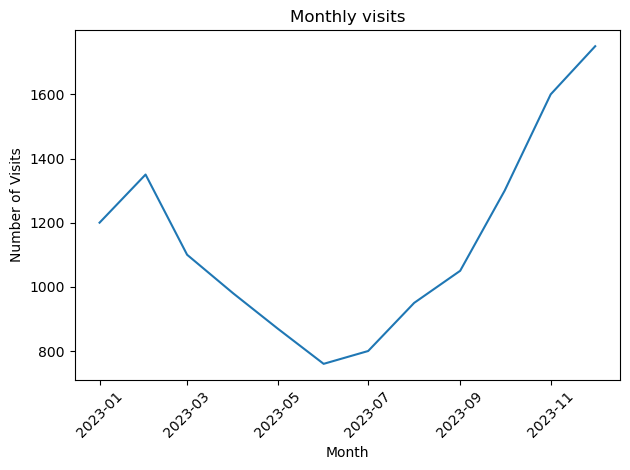

In [4]:
plt.plot(df_visits["month"], df_visits["visits"])
plt.title("Monthly visits")
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 4

In [5]:
df_visits["mobile_visits"] = [
    500, 600, 480, 420,
    380, 310, 340, 400,
    460, 580, 720, 800
]
df_visits.columns

Index(['month', 'visits', 'mobile_visits'], dtype='object')

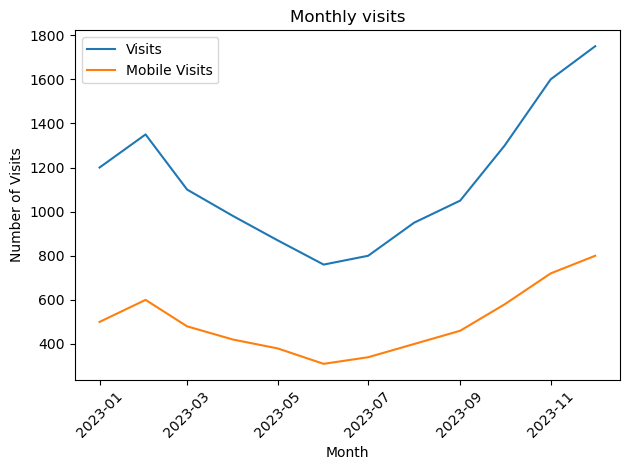

In [6]:
plt.plot(df_visits["month"], df_visits["visits"], label="Visits")
plt.plot(df_visits["month"], df_visits["mobile_visits"], label="Mobile Visits")

plt.title("Monthly visits")
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### Task 5

In [7]:
ag_df=pd.read_csv("2011_ag.csv")
print(ag_df.shape)
print(ag_df.head())
ag_df.columns

(50, 17)
  code       state category  total exports   beef  pork  poultry   dairy  \
0   AL     Alabama    state        1390.63   34.4  10.6    481.0    4.06   
1   AK      Alaska    state          13.31    0.2   0.1      0.0    0.19   
2   AZ     Arizona    state        1463.17   71.3  17.9      0.0  105.48   
3   AR    Arkansas    state        3586.02   53.2  29.4    562.9    3.53   
4   CA  California    state       16472.88  228.7  11.1    225.4  929.95   

   fruits fresh  fruits proc  total fruits  veggies fresh  veggies proc  \
0           8.0         17.1         25.11            5.5           8.9   
1           0.0          0.0          0.00            0.6           1.0   
2          19.3         41.0         60.27          147.5         239.4   
3           2.2          4.7          6.88            4.4           7.1   
4        2791.8       5944.6       8736.40          803.2        1303.5   

   total veggies  corn  wheat   cotton  
0          14.33  34.9   70.0   317.61  
1

Index(['code', 'state', 'category', 'total exports', 'beef', 'pork', 'poultry',
       'dairy', 'fruits fresh', 'fruits proc', 'total fruits', 'veggies fresh',
       'veggies proc', 'total veggies', 'corn', 'wheat', 'cotton'],
      dtype='object')

1. 50
2. The agricultural exports summaries
3. "code" column

### Task 6

In [8]:
df_sorted = ag_df.sort_values("total exports", ascending=False)
df_sorted.head()

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95
14,IA,Iowa,state,11273.76,289.8,1895.6,155.6,107.00,1.0,2.2,3.24,2.7,4.4,7.10,2529.8,3.1,0.00
12,IL,Illinois,state,8709.48,53.7,394.0,14.0,45.82,4.0,8.5,12.53,15.2,24.7,39.95,2228.5,223.8,0.00
22,MN,Minnesota,state,7192.33,112.3,740.4,189.2,218.05,2.5,5.4,7.91,45.9,74.5,120.37,1264.3,538.1,0.00
26,NE,Nebraska,state,7114.13,762.2,262.5,31.4,30.07,0.7,1.5,2.16,20.4,33.1,53.50,1735.9,292.3,0.00


1. California has the highest.

### Task 7

In [9]:
fig = px.choropleth(data_frame=ag_df, locations="code", locationmode="USA-states", color="total exports", scope="usa",color_continuous_scale="Greens",hover_name="state",title="2011 U.S. Agricultural Exports by State (Millions $)")
fig.show()

In [12]:
fig = px.choropleth(data_frame=ag_df, locations="code", locationmode="USA-states", color="total exports", scope="usa",color_continuous_scale="ylorRd",hover_name="state",title="2011 U.S. Agricultural Exports by State (Millions $)")
fig.show()

- The higher values of the scale stand out considerably more than the green scale.

### Task 9

In [13]:
cities = {
    "city": [
        "Fresno", "Des Moines", "Lubbock",
        "Yakima", "Bakersfield", "Salinas"
    ],
    "lat": [36.7, 41.6, 33.6, 46.6, 35.4, 36.7],
    "lon": [-119.8, -93.6, -101.8, -120.5, -119.0, -121.7],
    "export_value": [4200, 3100, 2800, 2200, 3900, 1800]
}

df_cities = pd.DataFrame(cities)

### Task 10

In [17]:
fig = px.scatter_geo(
    data_frame=df_cities,
    lat="lat",
    lon="lon",
    size='export_value',
    color='export_value',
    hover_name="city",
    scope='usa',
    title='Agricultural Export Value by City (Thousands $)',
    labels={"export_value": "Export Value ($K)"}
)
fig.show()

### Task 11:

In [19]:
fig = px.choropleth(data_frame=ag_df, locations="code", locationmode="USA-states", color="corn", scope="usa",color_continuous_scale="Greens",hover_name="state",title="2011 U.S. Corn Export by State")
fig.show()

The mid west dominates corn exports, this does match with what we would have expected.

### Task 12

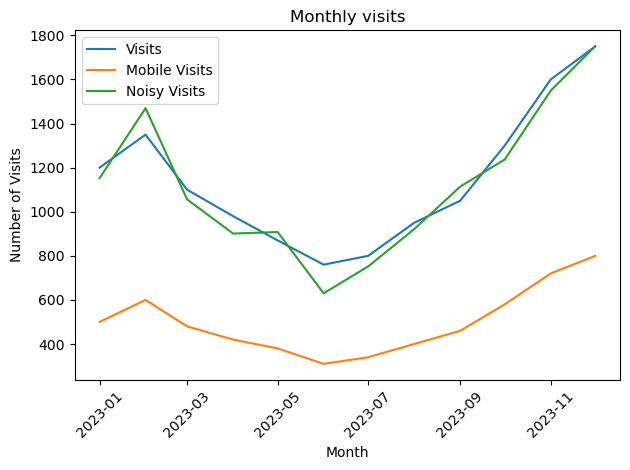

In [20]:
import numpy as np

np.random.seed(42)
df_visits["noisy_visits"] = (
    df_visits["visits"]
    + np.random.randint(-150, 150, size=len(df_visits))
)

plt.plot(df_visits["month"], df_visits["visits"], label="Visits")
plt.plot(df_visits["month"], df_visits["mobile_visits"], label="Mobile Visits")
plt.plot(df_visits["month"], df_visits["noisy_visits"], label="Noisy Visits")


plt.title("Monthly visits")
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

- Noisy Visits appears the "noisiest" with steeper inclines and declines compared to the other two lines. However, without our background knowledge it could be hard to tell. 
- This tells us that noise can be more obvious when you have a better understanding of expectations, but it could be hard to determine outright when it is not extreme.

### Task 13

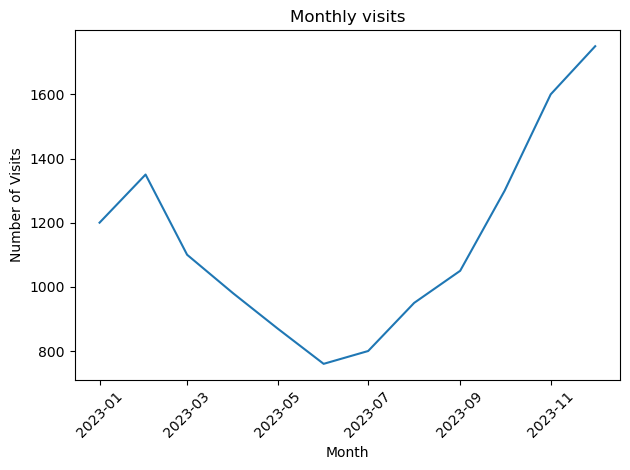

In [21]:
plt.plot(df_visits["month"], df_visits["visits"], label="Visits")
plt.title("Monthly visits")
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- The line shows a downward trend leading out of the holidays, with an upwards trend leading back into it, while still trending upward overall. In one sentence, we could say that the business is significantly more popular in the holiday season and should consider reducing hours in the spring and summer.

### Task 14

In [24]:
fig = px.choropleth(data_frame=ag_df,
    locations="code",
    locationmode="USA-states",
    color="total exports", 
    scope="usa",
    color_continuous_scale="Greens",
    hover_name="state",
    title="2011 U.S. Agricultural Exports by State (Millions $)",
    labels={"total exports": "Export Value in Millions"}
    )
fig.show()

- Redundant Encoding is representing information in different ways, via colors, shapes, labels etc.

- Because a reader who has trouble distinguishing colors would have to spend longer trying to visually parse the information presented to them.

### Task 15:

- A choropleth map shows regional data, while scatter maps will show you data at precise locations. Use would depend on the data you're presenting, such as whether or not you're categorizing an area of information, or trying to represent individual data points.

- It is very difficult to look at a bar chart and conceptualize the context and changes over time. Meanwhile, a line plot provides a line which very clearly guides you between data points.

- Pandas requires dates to be formatted in a particular way to be accurately graphed, and is necessary for time-series representation.